# Lecture 2 Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop

## Exercise 2.9

1. Specify which distrubitions are used and explain the resulting probabilities
2. What is the result of the following command: `stats.norm.ppf(stats.norm.cdf(2))`

In [ ]:
print(stats.norm.cdf(2))
#> 0.9772498680518208
print(stats.norm.cdf(2,1,1))
#> 0.8413447460685429
print(stats.norm.cdf(2,1,2))
#> 0.6914624612740131

0.9772498680518208
0.8413447460685429
0.6914624612740131


All of the distributions use the cumulative distribution function. We specify the growth to be around $x = 2$.

1. Output one can be rewritten as $\mathrm{N}(0,1) \approx 0.97$
2. Output two can be rewritten as $\mathrm{N}(1,1) \approx 0.84$
3. Output three as $\mathrm{N}(1,2) \approx 0.69$

The output we get is the percentile of how *much* of the normal distribution is under the quantile $x=2$.

In [5]:
print(stats.norm.ppf(stats.norm.cdf(2)))

2.0000000000000004


`ppf` or the 'Percent point function' asks at what $x$ value the input percentage is to the left of $x$. So for our input we ask "At what x value is 97% to the left of x" and we get $x = 2$

In [6]:
print(stats.norm.ppf(0.975))
#> 1.959963984540054

print(stats.norm.ppf(0.975,1,1))
#> 2.959963984540054

print(stats.norm.ppf(0.975,1,2))
#> 4.919927969080108

1.959963984540054
2.959963984540054
4.919927969080108


ppf tells us exactly at what $x$ value $0.975 \%$ of the area under the curve for the given normal distribution is.

<Axes: title={'center': 'Normal(mu=[0. 1. 1.], sigma=[1. 1. 2.])'}, xlabel='$x$', ylabel='$pdf$'>

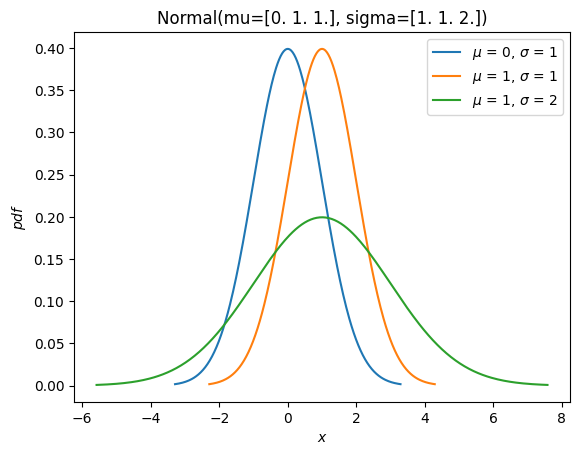

In [17]:
X = stats.Normal(mu=[0,1,1], sigma=[1,1, 2])
X.plot()

## Exercise 2.10

a)

1.0


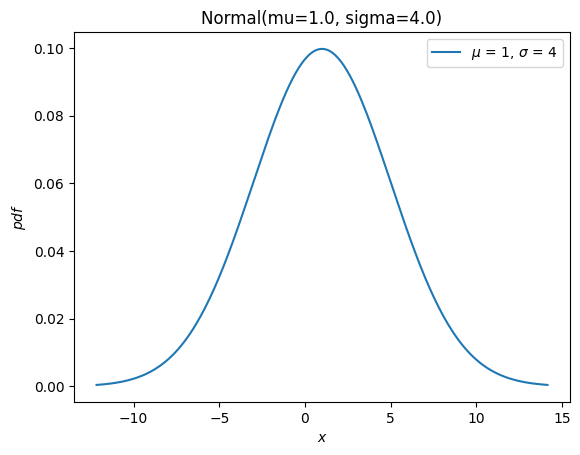

In [21]:
X = stats.Normal(mu=1, sigma=4)
X.plot()

print(X.cdf(np.inf) - X.cdf(- np.inf))


1. True - Always
2. True
3. False
4. True 
5. True

b)

In [35]:
X = stats.Normal(mu=24, sigma=16**0.5)

# P(X <= 20)
print(f"P(X <= 20)  = {X.cdf(20)}")
# P(X > 29.5)
print(f"P(X > 29.5) = {1 - X.cdf(29.5)}")
# P(X = 23.8)
print(f"P(X = 23.8) = {0}")




P(X <= 20)  = 0.15865525393145707
P(X > 29.5) = 0.08456572235133564
P(X = 23.8) = 0


The probability of any random variable $X$ being $x$ is always 0

$$ \mathrm{P}(X = x) = 0 $$

## Exercise 2.11

A machine for checking computer chips uses on average 65 milliseconds per
check with a standard deviation of 4 milliseconds. A newer machine, potentially to be bought, uses on average 54 milliseconds per check with a standard
deviation of 3 milliseconds. It can be used that check times can be assumed
normally distributed and independent.

a) What is the probability that the time savings per check using the new machine is less than 10 milliseconds is?

P(X > 10) = 0.42%


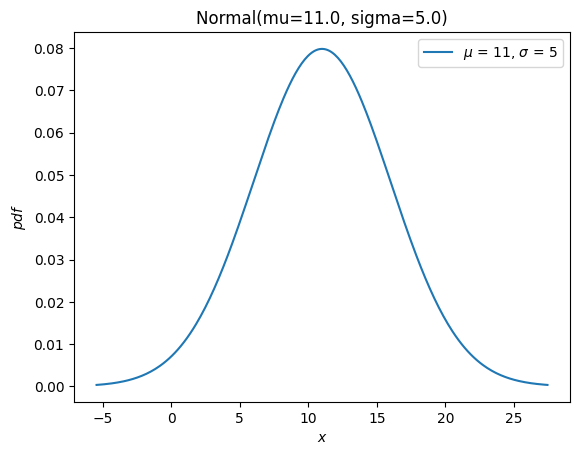

In [50]:
mu = 65
sigma = 4

old = stats.Normal(mu=65, sigma=4)

new_mu = 54
new_sigma = 3

new = stats.Normal(mu=54, sigma=3)

normalised = stats.Normal(mu=mu-new_mu, sigma=(sigma**2+new_sigma**2)**0.5)
normalised.plot()

print(f"P(X > 10) = {normalised.cdf(10):.2f}%")


b) What is the mean (μ) and standard deviation (σ) for the total time use for
checking 100 chips on the new machine is?

In [66]:
mu_total = new_mu*100
sigma_total = (new_sigma**2*100)**0.5

print(f"{mu_total} ms  {sigma_total} ms")

5400 ms  30.0 ms


## Exercise 2.12

A manufacturer of concrete items knows that the length (L) of his items are rea-
sonably normally distributed with $μ_{L} = 3000 \mathrm{mm}$ and $σ_{L} = 3 \mathrm{mm}$. The requirement for these elements is that the length should be not more than 3007 mm and the length must be at least 2993 mm.

a) The expected error rate in the manufacturing will be?

In [90]:
concrete_sigma = 3
concrete_mu = 3000
high_mean = 3007
low_mean = 2993

L_dist = stats.Normal(mu=concrete_mu, sigma=concrete_sigma)

length_diff = L_dist.cdf(high_mean) - L_dist.cdf(low_mean)

error = 1 - length_diff

print(error)



0.01963065725729063


b) The concrete items are supported by beams, where the distance between
the beams is called Lbeam and can be assumed normal distributed. The
concrete items length is still called L. For the items to be supported correctly, the following requirements for these lengths must be fulfilled: 90 mm <
L − Lbeam < 110 mm. It is assumed that the mean of the distance between
the beams is μbeam = 2900 mm. How large may the standard deviation
σbeam of the distance between the beams be if you want the requirement
fulfilled in 99% of the cases?

In [98]:
beam_mu = 2900

mean_diff = concrete_mu - beam_mu

z_score = stats.norm.ppf(0.995)
max_deviation = 10 

total_std = max_deviation / z_score

print(f"sigma_beam = {np.sqrt(total_std**2 - concrete_sigma**2)}")


sigma_beam = 2.4641073292602282


## Exercise 2.13

In 2013, there were 110,000 views of the DTU statistics videos that are avail-
able online. Assume first that the occurrence of views through 2014 follows a
Poisson process with a 2013 average: $λ_{\mathrm{365days}} = 110000$.

a) What is the probability that in a randomly chosen half an hour there is no
occurrence of views?

In [108]:
yearly_views = 110000
half_hours = 365*24*2

lambda_half_hour = yearly_views / half_hours

print(stats.poisson.pmf(0, lambda_half_hour))

0.0018761399841118896


b) There has just been a view, what is the probability that you have to wait
more than fifteen minutes for the next view?

In [107]:
print(stats.expon.sf(0.5, scale=1/lambda_half_hour))

0.043314431591698045
